# Energy Futures Forward Inflation OLS Model

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
energy_tickers = ["CL", "CO", "HO", "NG", "QS", "XB"]
inf_tickers    = ["FWISBP55", "FWISUS55"]

In [3]:
data_path = r"A:\BBGData\data"
inf_paths = [os.path.join(data_path, ticker + ".parquet") for ticker in inf_tickers]
df_inf    = (pd.read_parquet(
    path = inf_paths, engine = "pyarrow").
    assign(country = lambda x: np.where(x.security.str.split(" ").str[0] == "FWISBP55", "UK", "US")))

In [4]:
fut_path   = r"A:\BBGFuturesManager_backup_backup\data\PXFront"
fut_paths  = [os.path.join(fut_path, ticker + ".parquet") for ticker in energy_tickers]
df_fut_rtn = (pd.read_parquet(
    path = fut_paths, engine = "pyarrow").
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "fut_rtn").
    dropna())

# Trading Model

In [5]:
df_combined = (df_inf.pivot(
    index = "date", columns = "country", values = "value").
    apply(lambda x: np.log(x)).
    diff().
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "inf_diff").
    dropna().
    merge(right = df_fut_rtn, how = "inner", on = ["date"]))

In [6]:
def _get_exp_rtn_ols(df: pd.DataFrame) -> pd.DataFrame:
    
    df_tmp = (df.assign(
        vol_rtn = lambda x: x.fut_rtn * (0.1 / (x.fut_rtn.ewm(span = 10, adjust = False).std() * np.sqrt(252))))
        [["vol_rtn", "inf_diff"]].
        dropna())
    
    model = (sm.OLS(
        endog = df_tmp.vol_rtn,
        exog  = sm.add_constant(df_tmp.inf_diff)).
        fit())
    
    beta        = model.params[-1]
    beta_tvalue = model.tvalues[-1]
    
    df_out = (df.assign(
        beta       = beta,
        t_value    = beta_tvalue,
        signal_rtn = lambda x: np.sign(x.beta * x.inf_diff) * x.fut_rtn))
    
    return df_out

df_model = (df_combined.assign(
    group_var = lambda x: x.country + " " + x.security).
    set_index("date").
    groupby("group_var").
    apply(_get_exp_rtn_ols).
    drop(columns = ["group_var"]).
    reset_index())

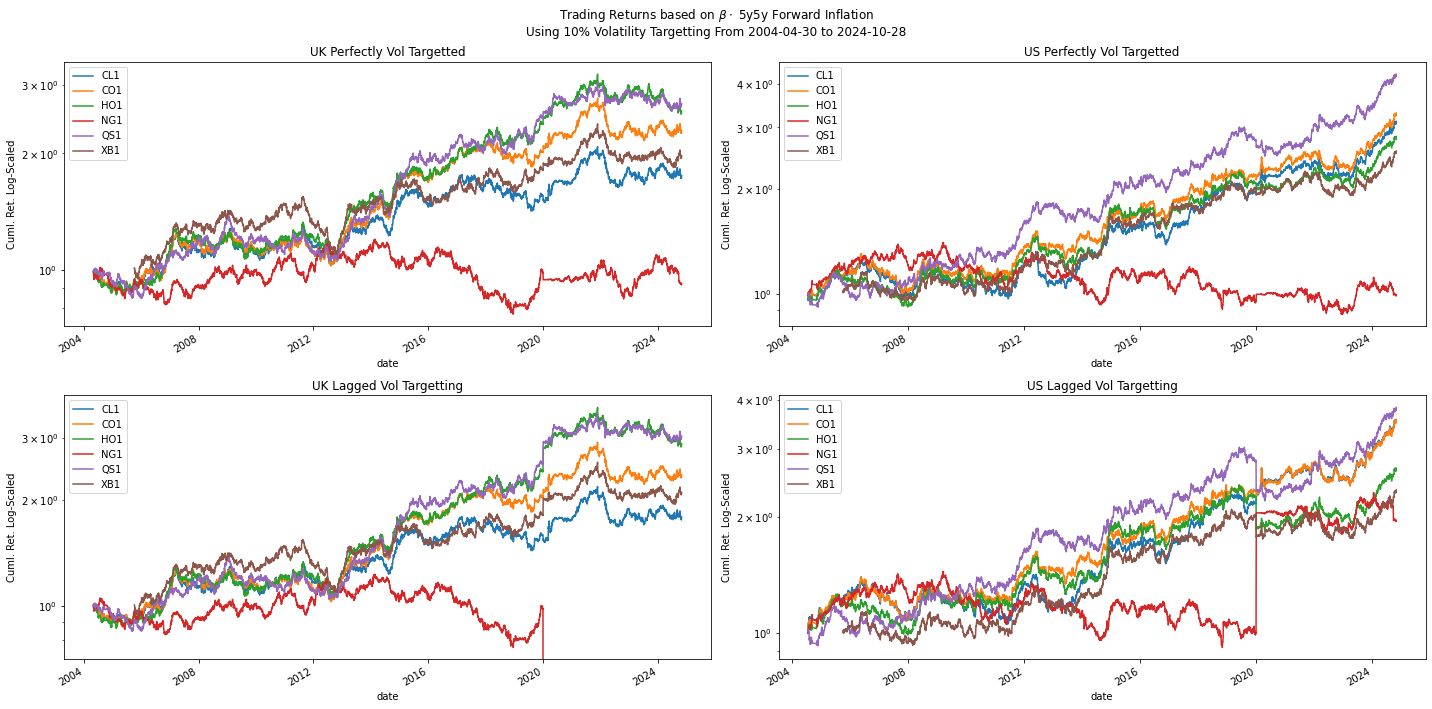

In [26]:
countries = df_model.country.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for i, country in enumerate(countries):
    
    df_wider = (df_model.query(
        "country == @country").
        rename(columns = {"security": ""}).
        pivot(index = "date", columns = "", values = "signal_rtn"))
    
    (df_wider.apply(
        lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            ax     = axes[0,i],
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} Perfectly Vol Targetted".format(country)))
    
    (df_wider.apply(
        lambda x: x * (0.1 / (x.ewm(span = 100, adjust = False).std().shift() * np.sqrt(252)))).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            ax     = axes[1,i],
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = "{} Lagged Vol Targetting".format(country)))

fig.suptitle(r"Trading Returns based on $\beta \cdot$ 5y5y Forward Inflation" + "\nUsing 10% Volatility Targetting From {} to {}".format(
    df_model.date.min().date(),
    df_model.date.max().date()))
plt.tight_layout()